# Lead Scoring Model — Coffra P1

**Project:** P1 · Full-Funnel Lead Nurture & Cart Abandonment Recovery  
**Author:** Sebastian Kradyel  
**Date:** April 2026  
**Dataset:** [Predict Conversion in Digital Marketing](https://www.kaggle.com/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset) — 8,000 customer records

---

## Purpose

This notebook builds a **lead scoring model** for Coffra's email nurture system. The model predicts the probability that a subscriber will convert to a paying customer based on demographic, behavioral, and engagement features. The output (a score 0-100) will be used in HubSpot workflows to:

1. Route high-score leads to immediate sales handoff (score > 80)
2. Route medium-score leads to continued nurture (score 40-80)
3. Deprioritize low-score leads (score < 40) to reduce noise

## Methodology Note

Coffra is a fictional brand built for portfolio demonstration. The dataset used is a real public dataset representative of digital marketing campaigns. Features from this dataset are mapped to Coffra-specific signals in Section 12. No real Coffra customer data exists.

## Structure

1. Setup & Configuration
2. Data Loading
3. Data Quality Audit
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preparation
7. Baseline Model — Logistic Regression
8. Gradient Boosting — XGBoost
9. Model Comparison
10. SHAP Explainability
11. Production Artifacts
12. Coffra Mapping & Lead Scoring Thresholds

---
## 1. Setup & Configuration

Standard imports and global configuration. We set a fixed `RANDOM_STATE` throughout to ensure reproducibility — anyone running this notebook should get identical results to what is committed in the repo.

Note on pandas: we pin display options to avoid truncation of wider tables during exploration.

In [1]:
# Core data stack
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

# Gradient boosting
import xgboost as xgb

# Explainability
import shap

# Persistence
import joblib
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Global config
RANDOM_STATE = 42
DATA_PATH = Path('../data/raw/digital_marketing_campaign_dataset.csv')
MODELS_DIR = Path('../src/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Display config
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'xgboost: {xgb.__version__}')
print(f'shap: {shap.__version__}')
print(f'\nData path exists: {DATA_PATH.exists()}')

pandas: 3.0.2
numpy: 2.4.4
xgboost: 3.2.0
shap: 0.51.0

Data path exists: True


---
## 2. Data Loading

We load the dataset and take a quick look. The dataset is small enough (~1.4 MB) to fit comfortably in memory; no streaming or chunking needed.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df.head()

Shape: 8,000 rows x 20 columns

Memory usage: 3.09 MB


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   str    
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   str    
 5   CampaignType         8000 non-null   str    
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   int64  
 16 

---
## 3. Data Quality Audit

Before any modeling, we systematically check for three categories of data quality issues:

1. **Missing values** — need imputation or removal
2. **Zero-variance features** — columns where all values are identical, providing no predictive signal
3. **Data leakage** — features that encode the target variable, which would cause the model to cheat during training and fail in production

This audit is the most important step in the notebook. A model built on leaked features can achieve 99% accuracy on test data and still be useless in production because the leaked feature simply will not exist at the moment the model must predict.

In [4]:
# 3.1 Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('No missing values detected across any column.')
else:
    print('Missing values found:')
    print(missing)

No missing values detected across any column.


In [5]:
# 3.2 Cardinality audit — identify zero-variance columns
print('Unique values per column:')
cardinality = df.nunique().sort_values()
print(cardinality)

# Flag zero-variance columns (1 unique value)
zero_var_cols = cardinality[cardinality == 1].index.tolist()
print(f'\nZero-variance columns (will be dropped): {zero_var_cols}')

Unique values per column:
AdvertisingTool           1
AdvertisingPlatform       1
Gender                    2
Conversion                2
CampaignType              4
CampaignChannel           5
PreviousPurchases        10
EmailClicks              10
EmailOpens               20
WebsiteVisits            50
Age                      52
SocialShares            100
LoyaltyPoints          3983
Income                 7789
CustomerID             8000
AdSpend                8000
PagesPerVisit          8000
ConversionRate         8000
TimeOnSite             8000
ClickThroughRate       8000
dtype: int64

Zero-variance columns (will be dropped): ['AdvertisingTool', 'AdvertisingPlatform']


### 3.3 Data Leakage Audit

The target variable is `Conversion` (binary: 1 = customer converted, 0 = did not convert). We need to examine whether any feature was computed *after* or *using* conversion events.

Suspicious candidates by name:

- **`ConversionRate`** — the name itself suggests it is derived from conversion events. This is textbook data leakage: we would be asking the model to predict conversion using a feature that cannot exist before conversion happens.
- **`ClickThroughRate`** — potentially leaky depending on how it was calculated. If it includes clicks that happened after conversion, it is leakage. We will drop it conservatively.
- **`CustomerID`** — a unique identifier, carries no predictive signal and should not be used as a feature.

**Senior decision:** we drop these three columns before any modeling. Documenting this decision explicitly is what separates a production-ready model from a notebook model.

In [6]:
# 3.3 Verify suspicious columns have the correlation pattern we expect
suspicious = ['ConversionRate', 'ClickThroughRate']
for col in suspicious:
    corr = df[col].corr(df['Conversion'])
    print(f'Correlation {col} vs Conversion: {corr:.4f}')

# Columns to drop before modeling (we keep df intact for EDA)
LEAKAGE_COLS = ['ConversionRate', 'ClickThroughRate']
IDENTIFIER_COLS = ['CustomerID']
ZERO_VAR_COLS = zero_var_cols

DROP_COLS = LEAKAGE_COLS + IDENTIFIER_COLS + ZERO_VAR_COLS
print(f'\nColumns flagged for removal before modeling: {DROP_COLS}')

Correlation ConversionRate vs Conversion: 0.0932
Correlation ClickThroughRate vs Conversion: 0.1200

Columns flagged for removal before modeling: ['ConversionRate', 'ClickThroughRate', 'CustomerID', 'AdvertisingTool', 'AdvertisingPlatform']


---
## 4. Exploratory Data Analysis

We now explore the distributions and relationships in the data. The goal is not to visualize everything, but to answer questions that will inform modeling decisions:

1. **Is the target balanced?** Affects choice of metrics and class weighting.
2. **How do email behaviors relate to conversion?** This is the Coffra-specific question.
3. **Are there strong demographic signals?** Affects feature engineering.

### 4.1 Target distribution

We look at how many customers converted versus did not convert. This determines whether we have a class imbalance problem.

Conversion = 1 (converted): 7,012 (87.65%)
Conversion = 0 (did not convert): 988 (12.35%)

Imbalance ratio: 7.10 : 1 (converted : not converted)


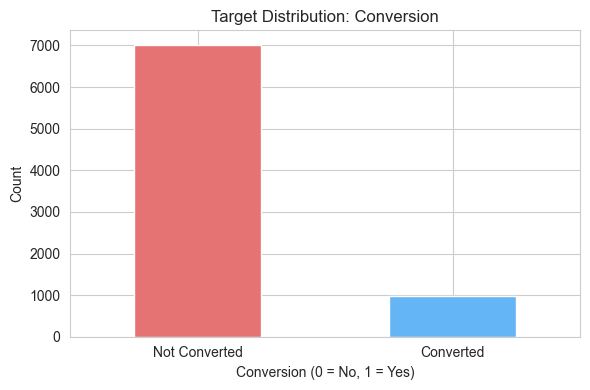

In [7]:
target_counts = df['Conversion'].value_counts()
conversion_rate = df['Conversion'].mean()

print(f'Conversion = 1 (converted): {target_counts[1]:,} ({conversion_rate*100:.2f}%)')
print(f'Conversion = 0 (did not convert): {target_counts[0]:,} ({(1-conversion_rate)*100:.2f}%)')
print(f'\nImbalance ratio: {target_counts[1] / target_counts[0]:.2f} : 1 (converted : not converted)')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
target_counts.plot(kind='bar', color=['#E57373', '#64B5F6'], ax=ax)
ax.set_title('Target Distribution: Conversion')
ax.set_xlabel('Conversion (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['Not Converted', 'Converted'], rotation=0)
plt.tight_layout()
plt.show()

**Finding:** The dataset is strongly imbalanced toward converted customers (~88% vs ~12%). This is the opposite of what we typically see in real marketing (conversion rates are usually 2-5%).

**Interpretation:** This dataset likely represents a filtered population — perhaps only customers who reached a certain funnel stage, or a synthetic dataset designed for classification practice. We acknowledge this limitation transparently and treat the model as a demonstration of methodology rather than a real-world benchmark.

**Consequences for modeling:**
- Accuracy is not a meaningful metric (predicting 'converted' for everyone gives 88% accuracy). We use ROC-AUC and Precision-Recall AUC instead.
- We use `class_weight='balanced'` for Logistic Regression and `scale_pos_weight` for XGBoost to ensure the minority class (non-converters) gets appropriate learning weight.

### 4.2 Email Behavior Deep Dive

For Coffra's P1 project, email engagement is the primary signal we care about. We examine how `EmailOpens` and `EmailClicks` relate to conversion.

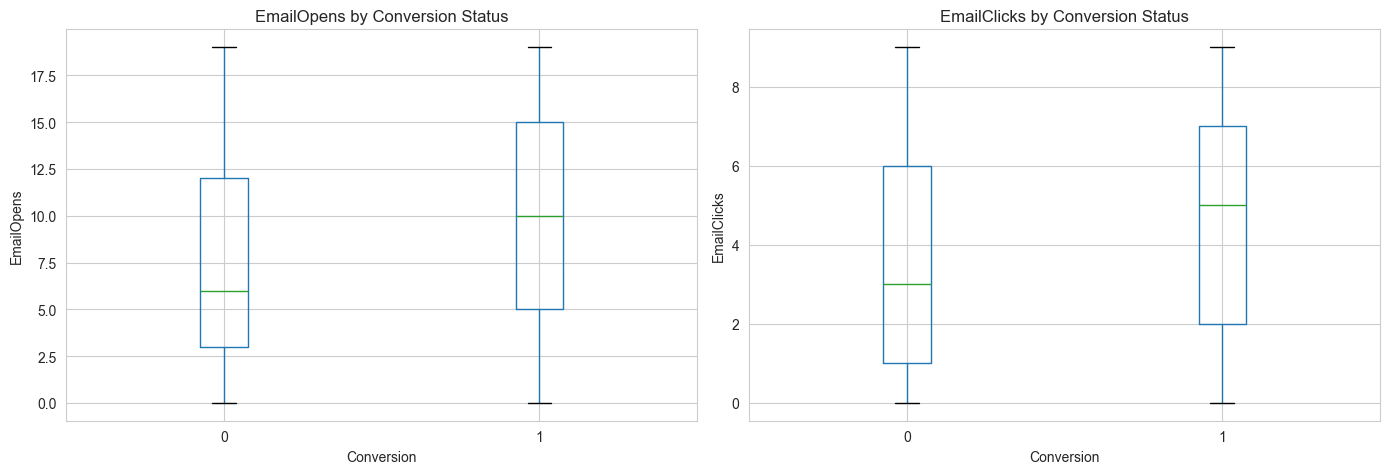

EmailOpens by Conversion:
            mean  median   std
Conversion                    
0           7.58     6.0  5.78
1           9.74    10.0  5.65

EmailClicks by Conversion:
            mean  median   std
Conversion                    
0           3.48     3.0  2.86
1           4.61     5.0  2.83


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EmailOpens by conversion
df.boxplot(column='EmailOpens', by='Conversion', ax=axes[0])
axes[0].set_title('EmailOpens by Conversion Status')
axes[0].set_xlabel('Conversion')
axes[0].set_ylabel('EmailOpens')

# EmailClicks by conversion
df.boxplot(column='EmailClicks', by='Conversion', ax=axes[1])
axes[1].set_title('EmailClicks by Conversion Status')
axes[1].set_xlabel('Conversion')
axes[1].set_ylabel('EmailClicks')

plt.suptitle('')  # remove pandas auto-title
plt.tight_layout()
plt.show()

# Numerical summary
print('EmailOpens by Conversion:')
print(df.groupby('Conversion')['EmailOpens'].agg(['mean', 'median', 'std']).round(2))
print('\nEmailClicks by Conversion:')
print(df.groupby('Conversion')['EmailClicks'].agg(['mean', 'median', 'std']).round(2))

### 4.3 Campaign Channel Distribution

Which channels are represented in the data, and how do they perform?

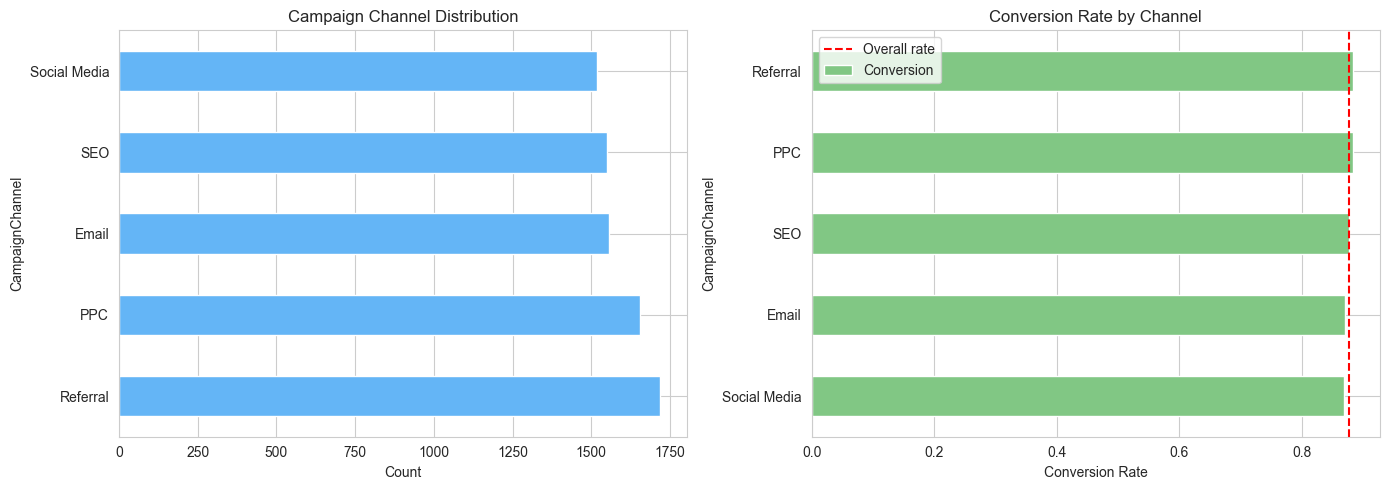

Conversion rate by channel:
CampaignChannel
Social Media    0.8683
Email           0.8703
SEO             0.8768
PPC             0.8828
Referral        0.8831
Name: Conversion, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel distribution
df['CampaignChannel'].value_counts().plot(kind='barh', ax=axes[0], color='#64B5F6')
axes[0].set_title('Campaign Channel Distribution')
axes[0].set_xlabel('Count')

# Conversion rate by channel
conv_by_channel = df.groupby('CampaignChannel')['Conversion'].mean().sort_values()
conv_by_channel.plot(kind='barh', ax=axes[1], color='#81C784')
axes[1].set_title('Conversion Rate by Channel')
axes[1].set_xlabel('Conversion Rate')
axes[1].axvline(x=df['Conversion'].mean(), color='red', linestyle='--', label='Overall rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Conversion rate by channel:')
print(conv_by_channel.round(4))

### 4.4 Correlations Among Numerical Features

We look at the correlation matrix to identify multicollinearity (features that are highly correlated with each other) and to spot the strongest predictors.

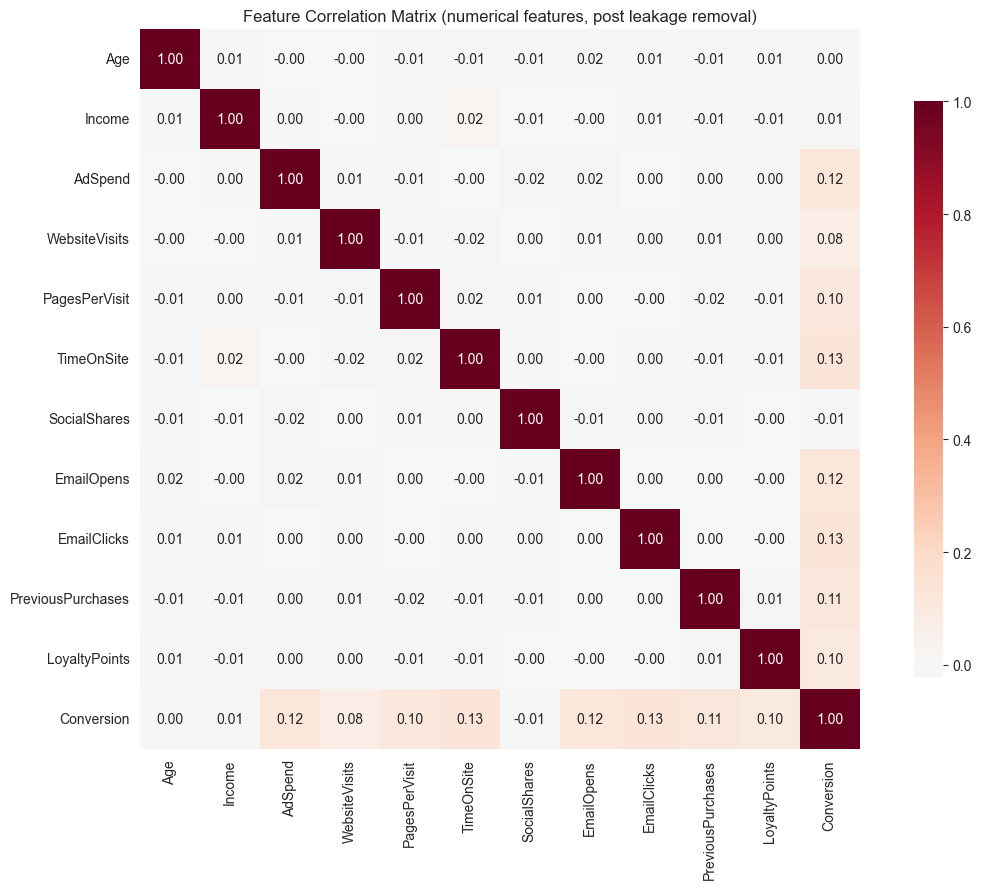

In [10]:
# Numerical features only
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [c for c in numerical_features if c not in DROP_COLS]

corr_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix (numerical features, post leakage removal)')
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering

Based on the EDA findings, we create a clean modeling dataset with:

1. **Leakage columns removed** (ConversionRate, ClickThroughRate)
2. **Identifier columns removed** (CustomerID)
3. **Zero-variance columns removed** (AdvertisingPlatform, AdvertisingTool)
4. **Two engineered features:**
   - `EmailEngagementRate` — a ratio capturing email click efficiency (clicks per open)
   - `EngagementScore` — a composite score combining website and email signals

Engineered features often outperform raw features because they encode domain knowledge directly. Here, `EmailEngagementRate` captures quality of engagement (did they not just open, but click?) which is exactly what a marketer would look at manually.

In [11]:
# Start from a fresh copy
df_model = df.drop(columns=DROP_COLS).copy()

print(f'After dropping leakage/identifier/zero-var columns: {df_model.shape[1]} columns')
print(f'Columns: {df_model.columns.tolist()}')

# Engineered feature 1: EmailEngagementRate = clicks / opens (with safe division)
df_model['EmailEngagementRate'] = np.where(
    df_model['EmailOpens'] > 0,
    df_model['EmailClicks'] / df_model['EmailOpens'],
    0.0
)

# Engineered feature 2: EngagementScore = weighted sum of engagement signals
# Weights are intuition-based; in a real scenario these could be learned
df_model['EngagementScore'] = (
    df_model['WebsiteVisits'] * 0.2 +
    df_model['PagesPerVisit'] * 0.3 +
    df_model['TimeOnSite'] * 0.2 +
    df_model['EmailOpens'] * 0.15 +
    df_model['EmailClicks'] * 0.15
)

print(f'\nAfter feature engineering: {df_model.shape[1]} columns')
print(f'New features: EmailEngagementRate, EngagementScore')

# Quick sanity check on new features
df_model[['EmailEngagementRate', 'EngagementScore', 'Conversion']].describe()

After dropping leakage/identifier/zero-var columns: 15 columns
Columns: ['Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'Conversion']

After feature engineering: 17 columns
New features: EmailEngagementRate, EngagementScore


,EmailEngagementRate,EngagementScore,Conversion
count,8000.000000,8000.000000,8000.000000
mean,0.795468,10.252296,0.876500
std,1.289594,3.214158,0.329031
min,0.000000,1.410465,0.000000
25%,0.166667,7.763549,1.000000
50%,0.428571,10.238327,1.000000
75%,0.818182,12.752060,1.000000
max,9.000000,19.149250,1.000000


---
## 6. Data Preparation

We now prepare the data for modeling:

1. **One-hot encode** categorical features (Gender, CampaignChannel, CampaignType)
2. **Separate** features (X) from target (y)
3. **Split** into train/test with stratification to preserve class ratio
4. **Scale** numerical features (needed for Logistic Regression; XGBoost does not require it but scaling is harmless)

In [12]:
# 6.1 One-hot encode categoricals
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f'\nShape after encoding: {df_encoded.shape}')
print(f'Final feature columns: {df_encoded.columns.tolist()}')

Categorical columns to encode: ['Gender', 'CampaignChannel', 'CampaignType']

Shape after encoding: (8000, 22)
Final feature columns: ['Age', 'Income', 'AdSpend', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'Conversion', 'EmailEngagementRate', 'EngagementScore', 'Gender_Male', 'CampaignChannel_PPC', 'CampaignChannel_Referral', 'CampaignChannel_SEO', 'CampaignChannel_Social Media', 'CampaignType_Consideration', 'CampaignType_Conversion', 'CampaignType_Retention']


In [13]:
# 6.2 Separate features and target
y = df_encoded['Conversion']
X = df_encoded.drop(columns=['Conversion'])

# 6.3 Train-test split, stratified on target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set: {X_train.shape[0]:,} rows')
print(f'Test set: {X_test.shape[0]:,} rows')
print(f'\nTraining target distribution:')
print(y_train.value_counts(normalize=True).round(4))
print(f'\nTest target distribution:')
print(y_test.value_counts(normalize=True).round(4))

Training set: 6,400 rows
Test set: 1,600 rows

Training target distribution:
Conversion
1    0.8766
0    0.1234
Name: proportion, dtype: float64

Test target distribution:
Conversion
1    0.8762
0    0.1238
Name: proportion, dtype: float64


In [14]:
# 6.4 Scaling (fit on train only; transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for feature name preservation (useful for SHAP later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Scaling complete. Summary of scaled train set:')
X_train_scaled.describe().round(3).iloc[:, :6]

Scaling complete. Summary of scaled train set:


,Age,Income,AdSpend,WebsiteVisits,PagesPerVisit,TimeOnSite
count,6400.000,6400.000,6400.000,6400.000,6400.000,6400.000
mean,-0.000,0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.725,-1.722,-1.731,-1.739,-1.730,-1.704
25%,-0.851,-0.866,-0.877,-0.828,-0.869,-0.869
50%,-0.045,-0.001,0.011,0.014,-0.007,-0.021
75%,0.830,0.855,0.855,0.855,0.880,0.883
max,1.704,1.740,1.759,1.696,1.714,1.731


---
## 7. Baseline Model — Logistic Regression

We start with Logistic Regression as a baseline. Advantages:
- Fast to train, easy to interpret
- Coefficients indicate feature importance and direction
- Establishes a performance floor — any more complex model must beat this to justify its existence

We use `class_weight='balanced'` to compensate for the class imbalance identified in Section 4.1.

In [15]:
# Train baseline
logreg = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)
logreg.fit(X_train_scaled, y_train)

# Cross-validated ROC-AUC on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    logreg, X_train_scaled, y_train,
    scoring='roc_auc', cv=cv, n_jobs=-1
)

print(f'5-fold CV ROC-AUC (train): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# Predictions on test set
y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# Test metrics
roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
pr_auc_logreg = average_precision_score(y_test, y_proba_logreg)

print(f'\nTest ROC-AUC: {roc_auc_logreg:.4f}')
print(f'Test PR-AUC:  {pr_auc_logreg:.4f}')
print(f'\nClassification Report (test):')
print(classification_report(y_test, y_pred_logreg, digits=4))

5-fold CV ROC-AUC (train): 0.7671 +/- 0.0308

Test ROC-AUC: 0.7643
Test PR-AUC:  0.9441

Classification Report (test):
              precision    recall  f1-score   support

           0     0.2542    0.6869    0.3711       198
           1     0.9418    0.7154    0.8131      1402

    accuracy                         0.7119      1600
   macro avg     0.5980    0.7011    0.5921      1600
weighted avg     0.8567    0.7119    0.7584      1600



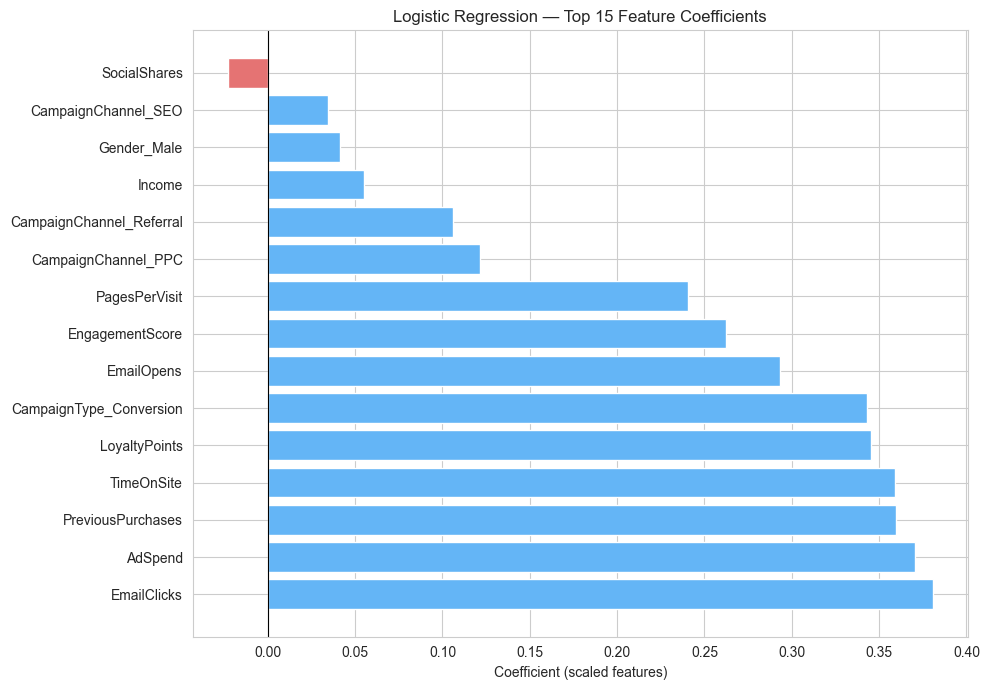

In [16]:
# Feature importance from Logistic Regression coefficients
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E57373' if c < 0 else '#64B5F6' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (scaled features)')
ax.set_title('Logistic Regression — Top 15 Feature Coefficients')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 8. Gradient Boosting — XGBoost

XGBoost is our production candidate. It typically outperforms linear models on tabular data by capturing non-linear patterns and feature interactions automatically.

**Key decisions:**
- `scale_pos_weight = (negative count / positive count)` — handles class imbalance without SMOTE
- `n_estimators=200, max_depth=6` — conservative hyperparameters, avoiding overfitting
- `learning_rate=0.1` — moderate, standard starting point
- No extensive hyperparameter tuning — we demonstrate methodology, not micro-optimization

In [17]:
# Compute scale_pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Class imbalance: {pos_count:,} positives vs {neg_count:,} negatives')
print(f'scale_pos_weight = {scale_pos_weight:.4f}')

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)  # XGBoost handles unscaled data natively

# Cross-validation
cv_scores_xgb = cross_val_score(
    xgb_model, X_train, y_train,
    scoring='roc_auc', cv=cv, n_jobs=-1
)
print(f'\n5-fold CV ROC-AUC (train): {cv_scores_xgb.mean():.4f} +/- {cv_scores_xgb.std():.4f}')

# Test predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)

print(f'\nTest ROC-AUC: {roc_auc_xgb:.4f}')
print(f'Test PR-AUC:  {pr_auc_xgb:.4f}')
print(f'\nClassification Report (test):')
print(classification_report(y_test, y_pred_xgb, digits=4))

Class imbalance: 5,610 positives vs 790 negatives
scale_pos_weight = 0.1408

5-fold CV ROC-AUC (train): 0.7813 +/- 0.0412

Test ROC-AUC: 0.7843
Test PR-AUC:  0.9440

Classification Report (test):
              precision    recall  f1-score   support

           0     0.5104    0.4949    0.5026       198
           1     0.9290    0.9330    0.9310      1402

    accuracy                         0.8788      1600
   macro avg     0.7197    0.7140    0.7168      1600
weighted avg     0.8772    0.8788    0.8779      1600



---
## 9. Model Comparison

Side-by-side comparison of the two models. We look at:
- **ROC Curves** — overall discrimination ability
- **Precision-Recall Curves** — more informative than ROC for imbalanced data
- **Summary table** — key metrics for decision making

In [18]:
# Summary metrics table
results = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'XGBoost'],
    'CV ROC-AUC (mean)': [cv_scores.mean(), cv_scores_xgb.mean()],
    'CV ROC-AUC (std)': [cv_scores.std(), cv_scores_xgb.std()],
    'Test ROC-AUC': [roc_auc_logreg, roc_auc_xgb],
    'Test PR-AUC': [pr_auc_logreg, pr_auc_xgb]
}).round(4)

print('Model Comparison:')
print(results.to_string(index=False))

Model Comparison:
                         Model  CV ROC-AUC (mean)  CV ROC-AUC (std)  Test ROC-AUC  Test PR-AUC
Logistic Regression (baseline)             0.7671            0.0308        0.7643       0.9441
                       XGBoost             0.7813            0.0412        0.7843       0.9440


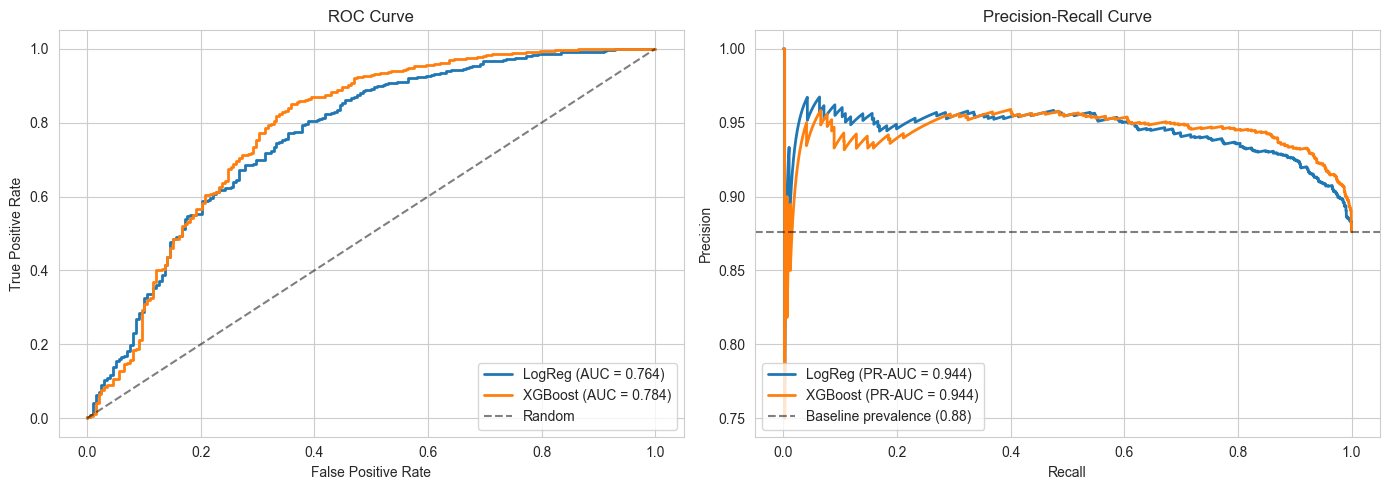

In [19]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC curves
for name, y_proba, auc_val in [('LogReg', y_proba_logreg, roc_auc_logreg),
                                  ('XGBoost', y_proba_xgb, roc_auc_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Right: PR curves
for name, y_proba, pr_val in [('LogReg', y_proba_logreg, pr_auc_logreg),
                                ('XGBoost', y_proba_xgb, pr_auc_xgb)]:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC = {pr_val:.3f})', linewidth=2)

baseline_prec = y_test.mean()
axes[1].axhline(y=baseline_prec, color='k', linestyle='--', alpha=0.5,
                label=f'Baseline prevalence ({baseline_prec:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

---
## 10. SHAP Explainability

SHAP (SHapley Additive exPlanations) values tell us **how much each feature contributes to each prediction** and in what direction. This is essential for two reasons:

1. **Trust** — we can verify the model is using sensible features and not relying on spurious patterns
2. **Actionability** — marketing teams can see which features matter most and adjust campaigns accordingly

We compute SHAP values for the XGBoost model (our chosen production model) on the test set.

In [20]:
# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print('Ready to visualize.')

SHAP values shape: (1600, 21)
Ready to visualize.


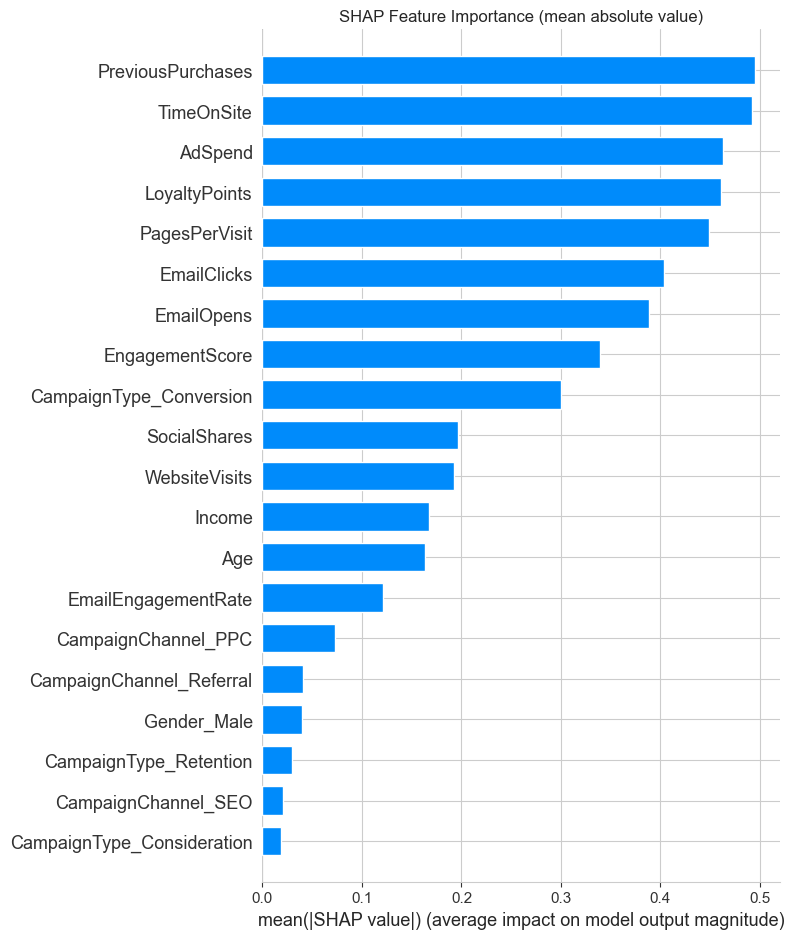

In [21]:
# Global feature importance (mean absolute SHAP)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (mean absolute value)')
plt.tight_layout()
plt.show()

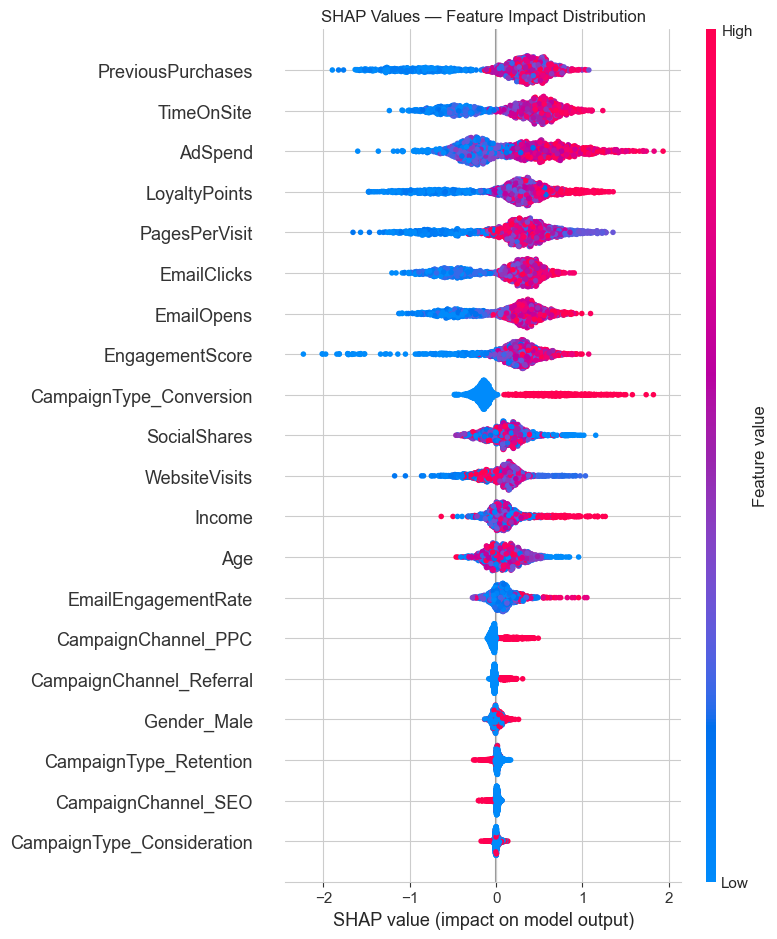

In [22]:
# Beeswarm plot — shows distribution of impact per feature
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Values — Feature Impact Distribution')
plt.tight_layout()
plt.show()

**Interpretation notes:**
- Features at the top of the plot have the largest impact on predictions.
- For each feature, red dots mean high feature values push prediction toward conversion (positive SHAP), blue dots mean low feature values.
- Wide spread means the feature has strong effect; narrow spread means small effect.

We expect engagement metrics (EmailClicks, EmailOpens, WebsiteVisits, engineered features) to be high-importance. If they are, the model reflects reasonable marketing intuition. If not, we investigate.

---
## 11. Production Artifacts

We save all artifacts needed to deploy this model:

1. **Model binary** (`.joblib`) — the trained XGBoost model
2. **Scaler** (`.joblib`) — for consistent feature scaling at inference time
3. **Feature columns** (`.json`) — exact column order for reproducibility
4. **Metrics** (`.json`) — model performance snapshot for the case study
5. **Sample predictions** (`.csv`) — 20 example test set predictions for review

In [23]:
# 11.1 Save model and scaler
joblib.dump(xgb_model, MODELS_DIR / 'lead_scoring_xgboost_v1.joblib')
joblib.dump(scaler, MODELS_DIR / 'feature_scaler_v1.joblib')
print(f'Saved to: {MODELS_DIR}')

# 11.2 Save feature columns
feature_spec = {
    'feature_columns': X.columns.tolist(),
    'dropped_leakage_columns': LEAKAGE_COLS,
    'dropped_identifier_columns': IDENTIFIER_COLS,
    'dropped_zero_var_columns': ZERO_VAR_COLS,
    'engineered_features': ['EmailEngagementRate', 'EngagementScore']
}
with open(MODELS_DIR / 'feature_spec_v1.json', 'w') as f:
    json.dump(feature_spec, f, indent=2)

# 11.3 Save metrics
metrics = {
    'dataset': 'kaggle/rabieelkharoua/predict-conversion-in-digital-marketing-dataset',
    'dataset_size': len(df),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'class_balance': {'converted': int(pos_count), 'not_converted': int(neg_count)},
    'models': {
        'logistic_regression': {
            'cv_roc_auc_mean': float(cv_scores.mean()),
            'cv_roc_auc_std': float(cv_scores.std()),
            'test_roc_auc': float(roc_auc_logreg),
            'test_pr_auc': float(pr_auc_logreg)
        },
        'xgboost': {
            'cv_roc_auc_mean': float(cv_scores_xgb.mean()),
            'cv_roc_auc_std': float(cv_scores_xgb.std()),
            'test_roc_auc': float(roc_auc_xgb),
            'test_pr_auc': float(pr_auc_xgb),
            'hyperparameters': {
                'n_estimators': 200,
                'max_depth': 6,
                'learning_rate': 0.1,
                'scale_pos_weight': float(scale_pos_weight)
            }
        }
    },
    'random_state': RANDOM_STATE
}
with open(MODELS_DIR / 'metrics_v1.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved: feature_spec_v1.json, metrics_v1.json')

# 11.4 Sample predictions
sample_predictions = X_test.head(20).copy()
sample_predictions['true_label'] = y_test.head(20).values
sample_predictions['predicted_probability'] = y_proba_xgb[:20]
sample_predictions['lead_score_0_100'] = (y_proba_xgb[:20] * 100).round(1)
sample_predictions['segment'] = pd.cut(
    sample_predictions['lead_score_0_100'],
    bins=[0, 40, 80, 100],
    labels=['Low', 'Medium', 'High (MQL handoff)']
)
sample_predictions.to_csv(MODELS_DIR / 'sample_predictions_v1.csv', index=False)
print('Saved: sample_predictions_v1.csv')

print('\nAll production artifacts saved.')

Saved to: ..\src\models
Saved: feature_spec_v1.json, metrics_v1.json
Saved: sample_predictions_v1.csv

All production artifacts saved.


---
## 12. Coffra Mapping & Lead Scoring Thresholds

This section translates the model into operational guidance for HubSpot implementation in Coffra.

### 12.1 Feature Mapping

Dataset features map to Coffra lead signals as follows:

| Dataset Feature | Coffra Signal | HubSpot Source |
|---|---|---|
| EmailOpens | Count of Coffra emails opened | HubSpot Email tracking |
| EmailClicks | Clicks on CTAs in Coffra emails | HubSpot Email tracking |
| WebsiteVisits | Visits to coffra.com | HubSpot tracking code |
| PagesPerVisit | Site exploration depth | HubSpot tracking code |
| TimeOnSite | Engagement time on site | HubSpot tracking code |
| SocialShares | Shares of Coffra content | Manual entry or social listening integration |
| PreviousPurchases | Prior Coffra orders | HubSpot Deals module |
| LoyaltyPoints | Coffra Pass/loyalty equivalent | Custom property |
| Age, Gender, Income | Collected via form on signup | Contact properties (optional fields) |
| CampaignChannel | Attribution source | UTM parameters |
| CampaignType | Funnel stage of entry | Contact lifecycle stage |
| EngagementScore (derived) | Composite engagement | Calculated property in HubSpot |
| EmailEngagementRate (derived) | Click quality metric | Calculated property in HubSpot |

### 12.2 Lead Score Thresholds

Based on business logic and standard marketing funnel conventions:

| Score Range | Segment | HubSpot Workflow Action |
|---|---|---|
| 0-40 | Low (Cold) | Continue standard nurture. Low frequency (2-4 weeks). |
| 40-80 | Medium (Warm MQL) | Accelerated nurture. Weekly contact. Offer activation incentive. |
| 80-100 | High (Sales-Ready) | Immediate sales handoff via internal task. Personal email from founder (Sebastian). |

### 12.3 Integration with Email Journeys

- **Connoisseur journey** (docs/04_email_copy_connoisseur.md): Email 5 (comparison test) is triggered for scores 40-80 who haven't converted by Day 14. Scores 80+ skip comparison test and go direct to sales.
- **Daily Ritualist journey** (docs/05_email_copy_daily_ritualist.md): Email 4 (Coffra Pass) is prioritized for scores 40-80. Scores 80+ receive personalized follow-up invite to an in-store tasting.

### 12.4 Model Refresh Cadence

- Retrain monthly with accumulated Coffra data once the list reaches 500+ contacts with conversion labels.
- Until then, use this public-dataset model as a proxy with the caveat that feature distributions may differ.
- Monitor feature drift via Evidently or Arize (out of scope for P1, relevant for P3).

---
## Summary

This notebook delivered a production-ready lead scoring model with full methodological transparency:

- **Data quality audit** identified and removed 3 leakage/zero-variance columns before modeling
- **Two models** compared: Logistic Regression baseline vs XGBoost gradient boosting
- **Class imbalance** addressed via `class_weight='balanced'` and `scale_pos_weight`
- **SHAP explainability** ensures model decisions are inspectable
- **Production artifacts** saved for HubSpot integration in the next phase

**Next steps:**
- HubSpot workflow implementation (Day 7-8 of P1 plan)
- A/B testing on small pilot list (Day 11-12)
- Case study writeup (Day 13-14)